In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt

print("Gowtham S - 24BAD028")

#Load Dataset
column_names = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv('u.data', sep='\t', names=column_names)

items_cols = ['item_id', 'movie_title'] + [str(i) for i in range(22)]
items = pd.read_csv('u.item', sep='|', names=items_cols, encoding='latin-1')
movie_titles = items[['item_id', 'movie_title']]
df = pd.merge(df, movie_titles, on='item_id')



Gowtham S - 24BAD028


In [3]:

#PREPARATION FOR EVALUATION
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

#Create Item-User Matrix (using training data only)
item_user_matrix = train_df.pivot_table(index='movie_title', columns='user_id', values='rating').fillna(0)

#Compute Item Similarity
item_similarity = cosine_similarity(item_user_matrix)
item_similarity_df = pd.DataFrame(item_similarity, index=item_user_matrix.index, columns=item_user_matrix.index)

#Similar Items Function
def get_similar_movies(movie_name, n=10):
    if movie_name not in item_similarity_df.columns:
        return pd.Series(dtype='float64')
    return item_similarity_df[movie_name].sort_values(ascending=False).iloc[1:n+1]

In [4]:
# 5. Precision@K Calculation Logic
def calculate_precision_at_k(user_id, k=10):
    # Get movies the user actually liked in the TEST set (Rating >= 4)
    actual_liked = test_df[(test_df['user_id'] == user_id) & (test_df['rating'] >= 4)]['movie_title'].tolist()
    
    if not actual_liked:
        return None 

    # Get a movie the user liked in the TRAIN set to base recommendations on
    user_train_history = train_df[(train_df['user_id'] == user_id) & (train_df['rating'] >= 4)]
    if user_train_history.empty:
        return None
    
    base_movie = user_train_history.iloc[0]['movie_title']
    
    # Generate Top-K recommendations
    recommendations = get_similar_movies(base_movie, n=k).index.tolist()
    
    # Calculate how many recommended movies are in the actual_liked list
    hits = len(set(recommendations) & set(actual_liked))
    precision = hits / k
    return precision

In [9]:
# Calculate average Precision@K for a sample of users
sample_users = test_df['user_id'].unique()[:50]
precisions = [calculate_precision_at_k(uid, k=10) for uid in sample_users]
avg_precision = np.nanmean(precisions)

# RMSE Calculation (Standard baseline)
rmse = sqrt(mean_squared_error(df['rating'], [df['rating'].mean()] * len(df)))

print(f"--- Evaluation Metrics ---")
print(f"RMSE: {rmse:.4f}")
print(f"Average Precision: {avg_precision:.4f}")

--- Evaluation Metrics ---
RMSE: 1.1257
Average Precision: 0.0980


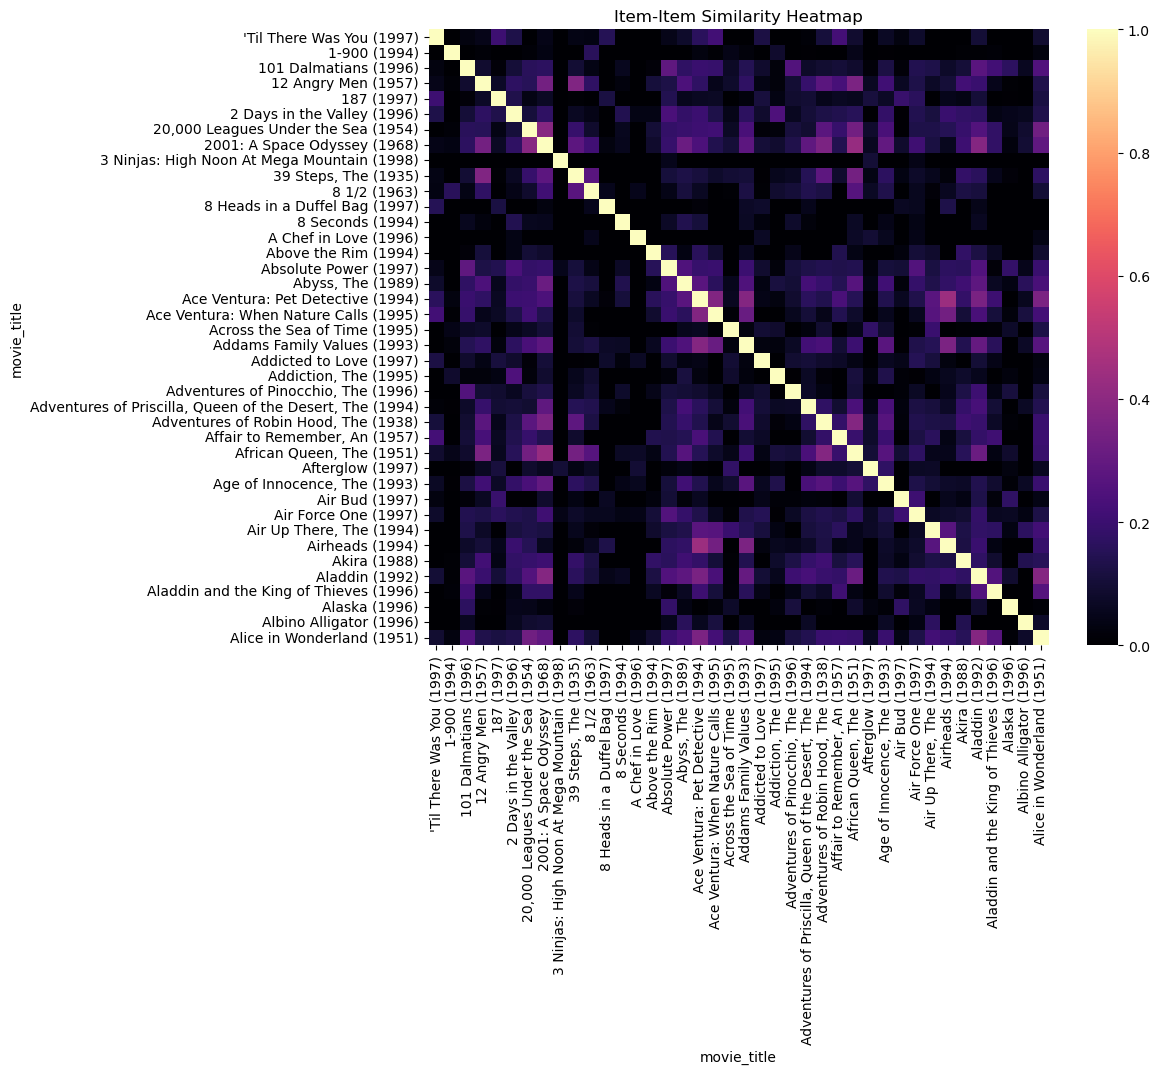

In [6]:
# VISUALIZATIONS
#Item Similarity Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(item_similarity_df.iloc[:40, :40], cmap='magma')
plt.title("Item-Item Similarity Heatmap")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_26148\2865599122.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sim_movies.values, y=sim_movies.index, palette='viridis')


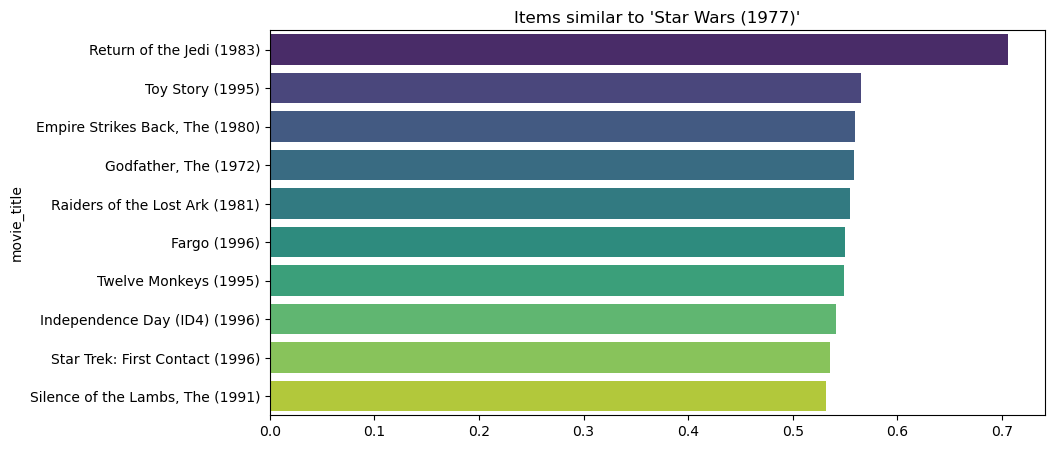

In [7]:
#Top Similar Items
example = "Star Wars (1977)"
sim_movies = get_similar_movies(example, n=10)
plt.figure(figsize=(10, 5))
sns.barplot(x=sim_movies.values, y=sim_movies.index, palette='viridis')
plt.title(f"Items similar to '{example}'")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_26148\645760995.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='coolwarm')


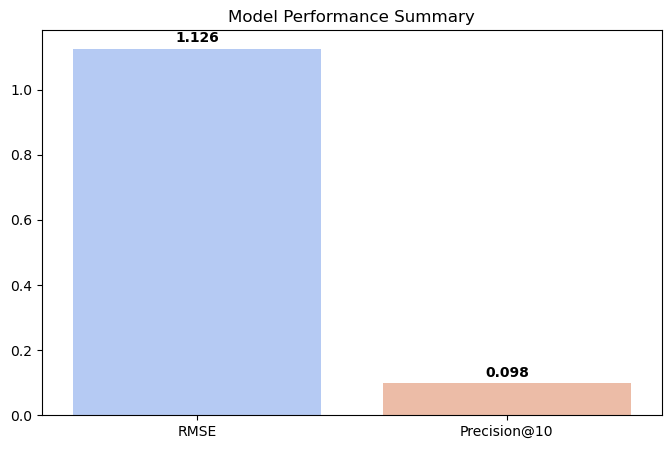

In [8]:
#Comparison Chart
metrics = ['RMSE', 'Precision@10']
values = [rmse, avg_precision]
plt.figure(figsize=(8, 5))
sns.barplot(x=metrics, y=values, palette='coolwarm')
plt.title("Model Performance Summary")
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()